In [15]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


df = pd.read_csv("../dataset/hopitaux.csv", sep="\t", header=None)
df.columns = ["t", "id1", "id2", "role1", "role2"]
df["duration"] = 20
df.head()


,t,id1,id2,role1,role2,duration
0,140,1157,1232,MED,ADM,20
1,160,1157,1191,MED,MED,20
2,500,1157,1159,MED,MED,20
3,520,1157,1159,MED,MED,20
4,560,1159,1191,MED,MED,20


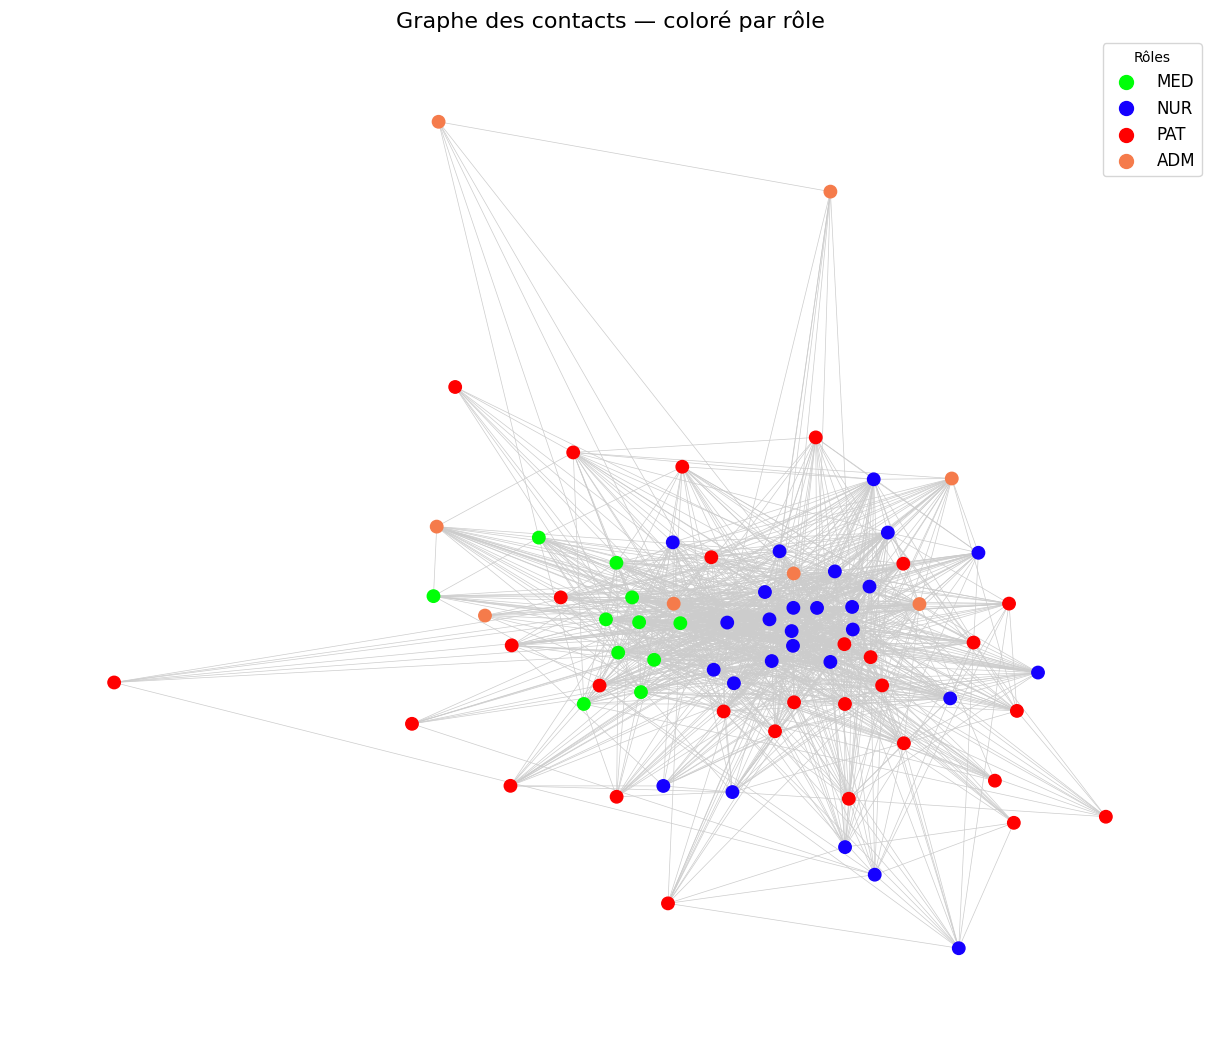

In [ ]:
# representation of the graph 
G = nx.Graph()

# Définir les couleurs pour chaque rôle
role_colors = {
    'MED': "#00FF08",  
    'NUR': "#1500FF", 
    'PAT': "#FF0000",  
    'ADM': "#F57B4B"   
}
nodes_info = {}
for _, row in df.iterrows():
    if row['id1'] not in nodes_info:
        nodes_info[row['id1']] = row['role1']
    if row['id2'] not in nodes_info:
        nodes_info[row['id2']] = row['role2']

for node_id, role in nodes_info.items():
    G.add_node(node_id, role=role)

# Ajouter les arêtes avec le poids (nombre de contacts)
edge_weights = {}
for _, row in df.iterrows():
    edge = tuple(sorted([row['id1'], row['id2']]))
    edge_weights[edge] = edge_weights.get(edge, 0) + 1

for edge, weight in edge_weights.items():
    G.add_edge(edge[0], edge[1], weight=weight)

G.number_of_nodes(), G.number_of_edges()



# --- Récupérer les couleurs de chaque nœud selon leur rôle ---
node_colors = []
for node in G.nodes():
    role = G.nodes[node].get("role", "PAT")  # par défaut PAT si jamais
    node_colors.append(role_colors.get(role, "#000000"))

# --- Choisir une disposition visuelle ---
pos = nx.spring_layout(G, seed=42, k=0.4)  # force layout lisible

# --- Dessiner le graphe ---
plt.figure(figsize=(12, 10))

nx.draw(
    G,
    pos,
    with_labels=False,
    node_color=node_colors,
    node_size=80,
    edge_color="#CCCCCC",
    width=0.5,
)

# --- Construire une légende des rôles ---
for role, color in role_colors.items():
    plt.scatter([], [], color=color, label=role, s=100)

plt.legend(title="Rôles", fontsize=12)
plt.title("Graph of  contacts", fontsize=16)
plt.show()

In [ ]:
import networkx as nx

# Degree centrality
degree_centrality = nx.degree_centrality(G)


# Betweenness centrality 
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)

# Closeness centrality 
closeness = nx.closeness_centrality(G, distance='weight')

# Eigenvector centrality 
eigenvector = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

strength = {
    node: sum(d["weight"] for _, _, d in G.edges(node, data=True))
    for node in G.nodes()
}

# DIsPLAY RESULTS
import pandas as pd

centrality_df = pd.DataFrame({
    "role": [G.nodes[n]["role"] for n in G.nodes()],
    "degree": [G.degree(n) for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "closeness": [closeness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()],
    "strength": [strength[n] for n in G.nodes()],
}, index=G.nodes())


hubs = centrality_df.sort_values(by="degree", ascending=False).head(10)
hubs



# Les individus ayant les degrees les plus élevés sont principalement les infirmiers (NUR) et quelques médecins (MED).
# Cela reflète la nature de leurs fonctions : les infirmiers circulent souvent entre plusieurs patients et services, et sont donc en interaction avec un grand nombre de personnes.
# Les médecins, bien que moins présents dans le top 10, occupent aussi des rôles centraux en raison de leurs tournées et consultations.






,role,degree,degree_centrality,betweenness,closeness,eigenvector,strength
1098,ADM,61,0.824324,0.066678,0.415730,0.108361,1480
1193,NUR,58,0.783784,0.017162,0.354067,0.180667,2236
1164,NUR,57,0.770270,0.032107,0.359223,0.156347,2109
1115,NUR,57,0.770270,0.010626,0.362745,0.495839,4286
1295,NUR,56,0.756757,0.003829,0.330357,0.246423,3695
1210,NUR,56,0.756757,0.070758,0.408840,0.486695,4077
1109,NUR,55,0.743243,0.031685,0.362745,0.211188,1711
1157,MED,53,0.716216,0.010095,0.377551,0.093193,2849
1658,ADM,51,0.689189,0.053721,0.375635,0.178912,1242
1144,MED,50,0.675676,0.017392,0.359223,0.077556,2045


In [ ]:
super_contactors = centrality_df.sort_values(by="strength", ascending=False).head(10)
super_contactors
# Les super-contactors identifiés par la mesure de strength sont presque exclusivement des infirmiers (NUR).
# Cela s’explique par le fait que les infirmiers passent la majeure partie de leur journée en interaction directe avec les patients, souvent pendant des périodes prolongées (soins, surveillance, accompagnement).

,role,degree,degree_centrality,betweenness,closeness,eigenvector,strength
1115,NUR,57,0.770270,0.010626,0.362745,0.495839,4286
1210,NUR,56,0.756757,0.070758,0.408840,0.486695,4077
1295,NUR,56,0.756757,0.003829,0.330357,0.246423,3695
1207,NUR,49,0.662162,0.041325,0.373737,0.365385,3130
1157,MED,53,0.716216,0.010095,0.377551,0.093193,2849
1193,NUR,58,0.783784,0.017162,0.354067,0.180667,2236
1164,NUR,57,0.770270,0.032107,0.359223,0.156347,2109
1221,MED,41,0.554054,0.038122,0.400000,0.061605,2075
1144,MED,50,0.675676,0.017392,0.359223,0.077556,2045
1149,NUR,48,0.648649,0.002922,0.321739,0.146558,1934


In [ ]:

bridges = centrality_df.sort_values(by="betweenness", ascending=False).head(10)
bridges

# Les individus ayant une betweenness élevée agissent comme des ponts structurels entre différentes communautés du réseau (les retirer pourrait fragmenter le réseau en plusieurs composantes.

,role,degree,degree_centrality,betweenness,closeness,eigenvector,strength
1142,NUR,41,0.554054,0.183147,0.471338,0.011824,249
1210,NUR,56,0.756757,0.070758,0.408840,0.486695,4077
1098,ADM,61,0.824324,0.066678,0.415730,0.108361,1480
1209,ADM,24,0.324324,0.055327,0.406593,0.006497,161
1658,ADM,51,0.689189,0.053721,0.375635,0.178912,1242
1100,NUR,28,0.378378,0.053417,0.400000,0.010052,288
1114,NUR,45,0.608108,0.052982,0.400000,0.121969,1335
1261,NUR,27,0.364865,0.047130,0.385417,0.005297,202
1202,NUR,43,0.581081,0.043261,0.391534,0.034688,763
1205,NUR,49,0.662162,0.043179,0.383420,0.069827,1105
